
Optimizing for GELU

>>> GELU: running differential_evolution ...
    DE found loss 1.363726e-04 with params [ 3.50340870e-01 -2.56693695e-05]
>>> GELU: running basinhopping ...
    Basinhopping found loss 1.363723e-04 with params [ 3.50285257e-01 -5.47597816e-09]
>>> GELU: running shgo ...
    SHGO skipped: shgo() got an unexpected keyword argument 'seed'
>>> GELU: local method 'Nelder-Mead' with 8 starts ...
>>> GELU: local method 'Powell' with 8 starts ...
        Start 1: loss 1.363723e-04, params [3.50285084e-01 3.20779974e-10]
>>> GELU: local method 'BFGS' with 8 starts ...
>>> GELU: local method 'L-BFGS-B' with 8 starts ...


/tmp/ipykernel_1275/1608286661.py:147: OptimizeWarning: Unknown solver options: disp
  res = minimize(


>>> GELU: local method 'SLSQP' with 8 starts ...
>>> GELU: local method 'TNC' with 8 starts ...


/tmp/ipykernel_1275/1608286661.py:147: OptimizeWarning: Unknown solver options: maxiter
  res = minimize(


>>> GELU: local method 'COBYLA' with 8 starts ...
>>> GELU: local method 'trust-constr' with 8 starts ...


...

>>> Mish: local method 'SLSQP' with 8 starts ...
>>> Mish: local method 'TNC' with 8 starts ...


/tmp/ipykernel_1275/1608286661.py:147: OptimizeWarning: Unknown solver options: maxiter
  res = minimize(


>>> Mish: local method 'COBYLA' with 8 starts ...
>>> Mish: local method 'trust-constr' with 8 starts ...


/root/miniconda3/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:385: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)



>>> Mish:
    Optimized: a=0.219615, b=0.167133, MSE=5.422430e-04, MAE=1.717024e-02

=== OPTIMIZED PARAMETERS AND LOSSES ===
GELU: a = 0.35028508, b = 0.00000000, MSE = 1.363723e-04, MAE = 8.943164e-03
SWISH: a = 0.14575758, b = -0.00000000, MSE = 2.516629e-04, MAE = 1.384938e-02
MISH: a = 0.21961491, b = 0.16713308, MSE = 5.422430e-04, MAE = 1.717024e-02


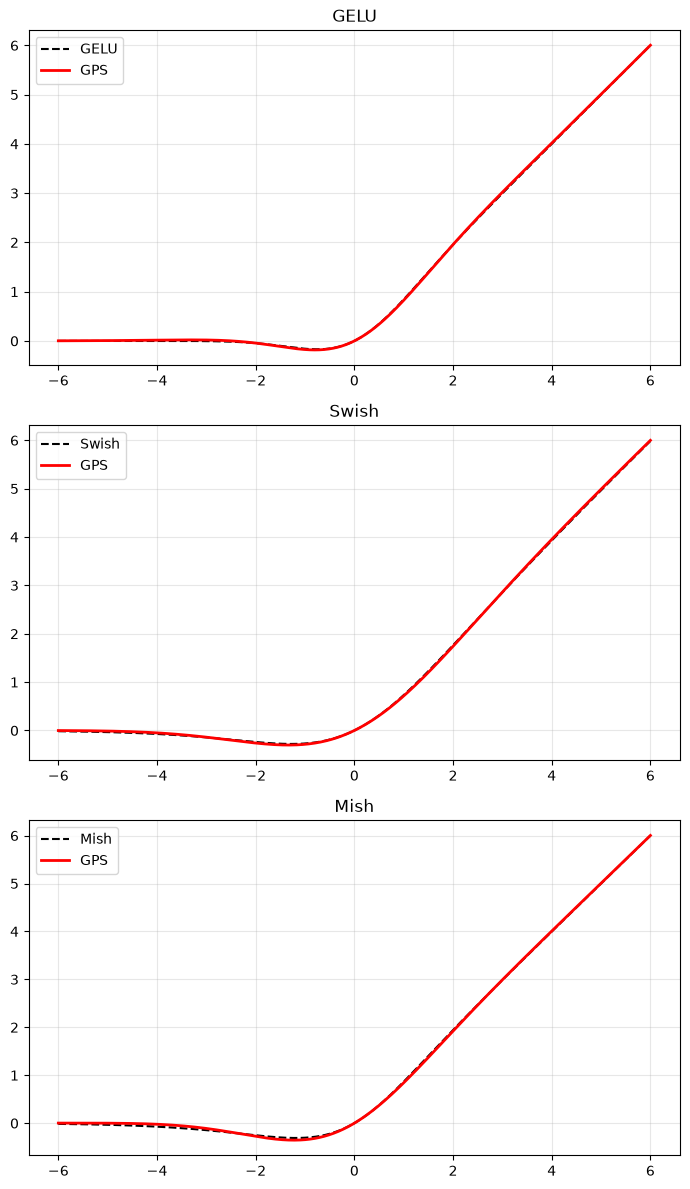


Optimization finished. Plot saved as 'activation_fits.png'.


In [5]:
#!/usr/bin/env python3
"""
Approximate common activation functions (GELU, Swish, Mish) using the
Gaussian‑decay softplus: f(x) = softplus(x) - ln(2) * exp(-a*x^2 - b*x).

The script uses SciPy's optimizers with multiple starts and global search to
find the best (a, b) for each target. It prints the optimized parameters,
MSE, and MAE for each activation.
"""

import numpy as np
from scipy.special import erf
from scipy.optimize import (
    minimize, differential_evolution, basinhopping, shgo,
)
import matplotlib.pyplot as plt

# ----------------------------- activation definitions -------------------------

def softplus(x):
    """Stable softplus: max(x,0) + log(1 + exp(-|x|))."""
    return np.maximum(x, 0.0) + np.log1p(np.exp(-np.abs(x)))

def gaussian_decay_softplus(x, a, b):
    """
    Our activation: softplus(x) - ln(2) * exp(-a*x^2 - b*x).
    Clips exponent to avoid overflow.
    """
    exponent = -a * x**2 - b * x
    exponent = np.clip(exponent, -80.0, 80.0)   # safe for exp
    return softplus(x) - np.log(2.0) * np.exp(exponent)

# Target activations
def gelu(x):
    """Gaussian Error Linear Unit."""
    return 0.5 * x * (1.0 + erf(x / np.sqrt(2.0)))

def swish(x):
    """Swish: x * sigmoid(x) = x / (1 + exp(-x))."""
    return x / (1.0 + np.exp(-x))

def mish(x):
    """Mish: x * tanh(softplus(x))."""
    return x * np.tanh(softplus(x))

# Hand‑tuned parameters from the original kernel (for reference)
# Only GELU and Mish have known values; Swish does not have a pre‑tuned pair.
HAND_TUNED = {
    'gelu': (0.83893125, 0.00261370),
    'mish': (0.66335902, 0.25313827),
    # 'swish': (?, ?)  # no predefined – let the optimizer find it
}

# --------------------------- optimization infrastructure ---------------------

def mse_loss(params, target_func, x_grid):
    """Mean squared error."""
    a, b = params
    approx = gaussian_decay_softplus(x_grid, a, b)
    target = target_func(x_grid)
    return np.mean((approx - target) ** 2)

def mae_loss(params, target_func, x_grid):
    """Mean absolute error."""
    a, b = params
    approx = gaussian_decay_softplus(x_grid, a, b)
    target = target_func(x_grid)
    return np.mean(np.abs(approx - target))

def metrics(params, target_func, x_grid):
    """Return (MSE, MAE) for the given parameters."""
    return mse_loss(params, target_func, x_grid), mae_loss(params, target_func, x_grid)

def optimize_activation(target_func, target_name, x_grid, methods,
                        bounds_phys, n_random_starts=5, seed=42):
    """
    Run a suite of optimizers to find the best (a, b) for the given target.
    """
    rng = np.random.default_rng(seed)
    best_loss = np.inf
    best_params = None
    bounds = bounds_phys

    def objective(params):
        return mse_loss(params, target_func, x_grid)

    # 1) Differential Evolution
    print(f"\n>>> {target_name}: running differential_evolution ...")
    de_result = differential_evolution(
        objective,
        bounds=bounds,
        maxiter=1000,
        popsize=20,
        seed=seed,
        disp=False,
    )
    if de_result.success and de_result.fun < best_loss:
        best_loss = de_result.fun
        best_params = de_result.x
        print(f"    DE found loss {best_loss:.6e} with params {best_params}")

    # 2) Basinhopping
    print(f">>> {target_name}: running basinhopping ...")
    try:
        bh_result = basinhopping(
            objective,
            x0=np.array([0.5, 0.0]),
            niter=50,
            stepsize=0.5,
            minimizer_kwargs={'method': 'L-BFGS-B', 'bounds': bounds},
            seed=seed,
        )
        if bh_result.fun < best_loss:
            best_loss = bh_result.fun
            best_params = bh_result.x
            print(f"    Basinhopping found loss {best_loss:.6e} with params {best_params}")
    except Exception as e:
        print(f"    Basinhopping skipped: {e}")

    # 3) SHGO
    print(f">>> {target_name}: running shgo ...")
    try:
        shgo_result = shgo(
            objective,
            bounds=bounds,
            n=100,
            iters=3,
            sampling_method='simplicial',
            seed=seed,
        )
        if shgo_result.fun < best_loss:
            best_loss = shgo_result.fun
            best_params = shgo_result.x
            print(f"    SHGO found loss {best_loss:.6e} with params {best_params}")
    except Exception as e:
        print(f"    SHGO skipped: {e}")

    # 4) Local methods with multiple random starts
    for method in methods:
        print(f">>> {target_name}: local method '{method}' with {n_random_starts} starts ...")
        for i in range(n_random_starts):
            x0 = np.array([
                rng.uniform(bounds[0][0], bounds[0][1]),
                rng.uniform(bounds[1][0], bounds[1][1]),
            ])
            try:
                res = minimize(
                    objective,
                    x0,
                    method=method,
                    bounds=bounds if method in ('L-BFGS-B', 'TNC', 'SLSQP', 'trust-constr') else None,
                    options={'maxiter': 5000, 'disp': False},
                )
                if res.success and res.fun < best_loss:
                    best_loss = res.fun
                    best_params = res.x
                    print(f"        Start {i+1}: loss {best_loss:.6e}, params {best_params}")
            except Exception:
                pass

    return best_params, best_loss

# ----------------------------------- main ------------------------------------

x_grid = np.linspace(-8.0, 8.0, 20000)
bounds_phys = [(0.001, 5.0), (-5.0, 5.0)]

local_methods = [
    'Nelder-Mead', 'Powell', 'BFGS', 'L-BFGS-B',
    'SLSQP', 'TNC', 'COBYLA', 'trust-constr',
]

targets = {
    'GELU': gelu,
    'Swish': swish,          # replaced SERF with Swish
    'Mish': mish,
}

results = {}  # name -> (params, mse, mae)

for name, func in targets.items():
    print(f"\n{'='*60}\nOptimizing for {name.upper()}")
    best_params, best_loss = optimize_activation(
        func, name, x_grid, local_methods, bounds_phys,
        n_random_starts=8, seed=42
    )
    best_mse, best_mae = metrics(best_params, func, x_grid)
    results[name] = (best_params, best_mse, best_mae)

    # Compare with hand‑tuned if available
    if name in HAND_TUNED:
        ht_params = HAND_TUNED[name]
        ht_mse, ht_mae = metrics(ht_params, func, x_grid)
        print(f"\n>>> {name}:")
        print(f"    Optimized: a={best_params[0]:.6f}, b={best_params[1]:.6f}, MSE={best_mse:.6e}, MAE={best_mae:.6e}")
        print(f"    Hand‑tuned: a={ht_params[0]:.6f}, b={ht_params[1]:.6f}, MSE={ht_mse:.6e}, MAE={ht_mae:.6e}")
        print(f"    Improvement (MSE): {ht_mse - best_mse:.6e}")
    else:
        print(f"\n>>> {name}:")
        print(f"    Optimized: a={best_params[0]:.6f}, b={best_params[1]:.6f}, MSE={best_mse:.6e}, MAE={best_mae:.6e}")

# -------- FINAL SUMMARY (optimized parameters + losses) --------
print("\n" + "="*60)
print("=== OPTIMIZED PARAMETERS AND LOSSES ===")
for name, (params, mse, mae) in results.items():
    a, b = params
    print(f"{name.upper()}: a = {a:.8f}, b = {b:.8f}, MSE = {mse:.6e}, MAE = {mae:.6e}")
print("="*60)

# Plot – stacked vertically
fig, axes = plt.subplots(3, 1, figsize=(7, 12))          # <-- changed to vertical layout
plt.subplots_adjust(hspace=0.4)                          # add space between subplots
x_plot = np.linspace(-6, 6, 500)
for ax, (name, func) in zip(axes, targets.items()):
    params, _, _ = results[name]
    a, b = params
    approx = gaussian_decay_softplus(x_plot, a, b)
    target = func(x_plot)
    ax.plot(x_plot, target, 'k--', label=f'{name}')
    ax.plot(x_plot, approx, 'r-', label=f'GPS', lw=2)
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('activation_fits.png', dpi=150)
plt.show()
print("\nOptimization finished. Plot saved as 'activation_fits.png'.")

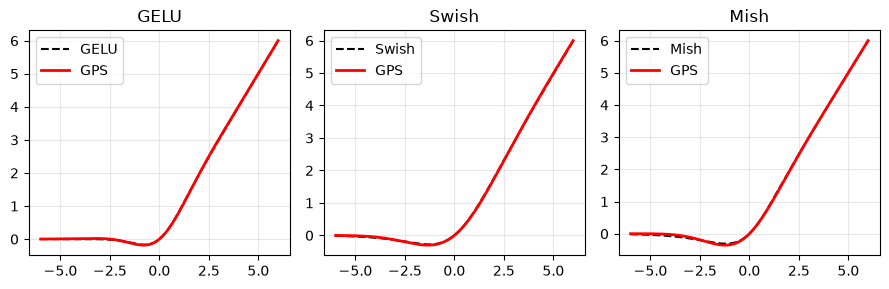

In [8]:
# Plot – stacked vertically
fig, axes = plt.subplots(1, 3, figsize=(3 * 3, 3))          # <-- changed to vertical layout
plt.subplots_adjust(hspace=0.4)                          # add space between subplots
x_plot = np.linspace(-6, 6, 500)
for ax, (name, func) in zip(axes, targets.items()):
    params, _, _ = results[name]
    a, b = params
    approx = gaussian_decay_softplus(x_plot, a, b)
    target = func(x_plot)
    ax.plot(x_plot, target, 'k--', label=f'{name}')
    ax.plot(x_plot, approx, 'r-', label=f'GPS', lw=2)
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('activation_fits.png', dpi=150)
plt.show()